## **1ª Etapa**: Análise Exploratória e Limpeza do Dataset ##

[Link do Dataset no Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)

In [43]:
import pandas as pd
import ast
import numpy as np

df = pd.read_csv('archive/movies_metadata.csv')

Análise Exploratória do Dataset

In [44]:
# Vamos começar conhecendo melhor as features (variáveis independentes) que possuímos
df.head(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  bool   
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  int64  
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45463 non-null  float64
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [45]:
df.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92


Primeiramente, vamos eliminar algumas variáveis que não serão aplicadas ao modelo. As selecionadas foram as seguintes:

- homepage: Página de publicidade do filme
- poster_path: ID do banner do filme (Localizável em: image.tmdb.org/t/p/w185/ID)
- status: Se já foi lançado ou não (Como o Dataset é de 2017, todos os filmes já devem ter sido lançados)
- video: 

In [46]:
df.drop(['homepage', 'poster_path', 'status', 'video', 'production_companies', 'tagline'], axis=1, inplace= True)

In [47]:
df.head(3)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Grumpier Old Men,6.5,92


Como podemos observar, as variáveis a seguir foram categorizadas como object, quando na realidade deveriam ser numéricas ou booleanos
- adult: Booleano (False/True)
- budget: Numérico (Dinheiro)
- release_date: Numérico (Data de Lançamento)
- popularity: Numérico ()

In [48]:
# Conferindo se há valores além de "True" e "False" na coluna
df['adult'].unique()

# Substituindo as strings "True" e "False" pelos valores booleanos
df['adult'] = df['adult'] == 'True'

In [49]:
# Analisando quais são os caracteres presentes dentro da coluna budget.
df['budget'].astype(str).apply(list).explode().unique()

# Como podemos observar no Output, a coluna contém somente numerais e nenhum ponto (.), o que indica que todos os valores são números inteiros
# Isso significa que podemos seguir com a conversão para integer diretamente
df['budget'] = df['budget'].astype('Int64')

In [50]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [51]:
df.head(2)

,adult,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Jumanji,6.9,2413


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   belongs_to_collection  4491 non-null   object        
 2   budget                 45463 non-null  Int64         
 3   genres                 45463 non-null  object        
 4   id                     45463 non-null  int64         
 5   imdb_id                45446 non-null  object        
 6   original_language      45452 non-null  object        
 7   original_title         45463 non-null  object        
 8   overview               44509 non-null  object        
 9   popularity             45463 non-null  float64       
 10  production_countries   45463 non-null  object        
 11  release_date           45379 non-null  datetime64[ns]
 12  revenue                45463 non-null  int64         
 13  r

In [66]:
# Para facilitar a visualização da tipagem dos dados, vamos reorganizar a tabela
nova_ordem_colunas = [
    # Booleana
    'adult',

    # Numéricas (Inteiros)
    'id', 'budget', 'revenue', 'vote_count',

    # Numéricas (Decimais / Floats)
    'popularity', 'runtime', 'vote_average',

    # Data
    'release_date',

    # Texto / Objeto (Descritivas)
    'title', 'original_title', 'overview',

    # Texto / Objeto (Listas/Metadados)
    'genres', 'belongs_to_collection', 'production_countries', 'spoken_languages',

    # Texto / Objeto (IDs/Código)
    'imdb_id', 'original_language'
]

df = df[nova_ordem_colunas]
df.head(5)

,adult,id,budget,revenue,vote_count,popularity,runtime,vote_average,release_date,title,original_title,overview,genres,belongs_to_collection,production_countries,spoken_languages,imdb_id,original_language
0,False,862,30000000,373554033,5415,21.946943,81.0,7.7,1995-10-30,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","{'id': 10194, 'name': 'Toy Story Collection', ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114709,en
1,False,8844,65000000,262797249,2413,17.015539,104.0,6.9,1995-12-15,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",{},"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",tt0113497,en
2,False,15602,0,0,92,11.712900,101.0,6.5,1995-12-22,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","{'id': 119050, 'name': 'Grumpy Old Men Collect...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113228,en
3,False,31357,16000000,81452156,34,3.859495,127.0,6.1,1995-12-22,Waiting to Exhale,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",{},"[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0114885,en
4,False,11862,0,76578911,173,8.387519,106.0,5.7,1995-02-10,Father of the Bride Part II,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]","{'id': 96871, 'name': 'Father of the Bride Col...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",tt0113041,en


In [ ]:
# Por último, a coluna belongs_to_collection possui 90% dos seus valores como NaN. Isso será um problema no treinamento do modelo.
# Para reverter isso, vamos desserializar os dados, convertendo todos para dicionários, incluindo os valores nulos
df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: x if pd.notna(x) else {} # Os valores NaN serão convertidos em dicionários vazios {}
)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  45463 non-null  bool          
 1   id                     45463 non-null  int64         
 2   budget                 45463 non-null  Int64         
 3   revenue                45463 non-null  int64         
 4   vote_count             45463 non-null  int64         
 5   popularity             45463 non-null  float64       
 6   runtime                45206 non-null  float64       
 7   vote_average           45463 non-null  float64       
 8   release_date           45379 non-null  datetime64[ns]
 9   title                  45463 non-null  object        
 10  original_title         45463 non-null  object        
 11  overview               44509 non-null  object        
 12  genres                 45463 non-null  object        
 13  b

## **2ª Etapa**: Segunda Análise Exploratória mais aprofundada ##

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # O Seaborn facilita a criação de gráficos estatísticos e usa o Matplotlib por baixo dos panos

# Configuração básica para visualização (opcional)
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 6) # Define um tamanho padrão para os gráficos

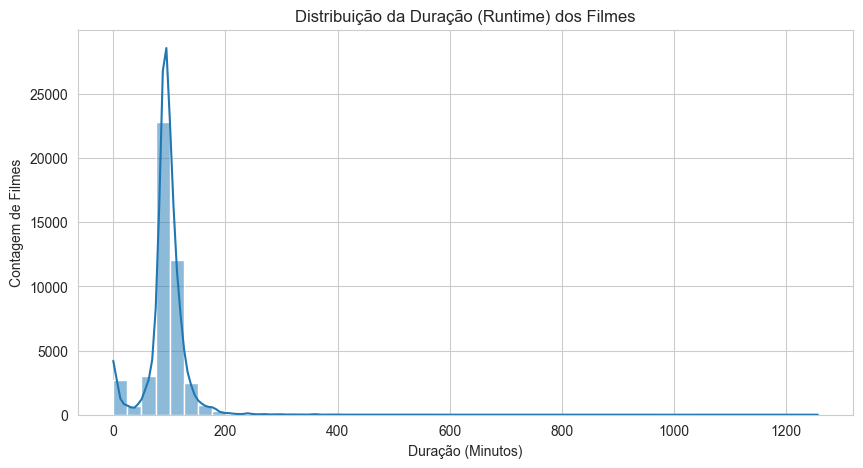

In [71]:
# Histograma: Mostra a distribuição de uma única variável
plt.figure(figsize=(10, 5))
sns.histplot(df['runtime'].dropna(), kde=True, bins=50) 
# Usamos dropna() para ignorar os NaNs
# kde=True adiciona uma estimativa da densidade (suaviza a curva)
plt.title('Distribuição da Duração (Runtime) dos Filmes')
plt.xlabel('Duração (Minutos)')
plt.ylabel('Contagem de Filmes')
plt.show()